# 자연어 전처리 - 토큰화 (Tokenization)


## 영어 토큰화 구현 (NLTK)


In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from transformers import AutoTokenizer

# NLTK 필수 리소스 다운로드
nltk.download("punkt")
# 최신 NLTK 버전 패치 대응 (punkt_tab 관련 에러 예방용)
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

english_text = (
    "Natural Language Processing is fascinating. We are learning Subword Tokenization!"
)

# ① 문장 토큰화 (Sentence Tokenization)
english_sentences = sent_tokenize(english_text)
print("--- 1. 영어 문장 토큰화 ---")
print(english_sentences)

# ② 단어 토큰화 (Word Tokenization)
english_words = word_tokenize(english_text)
print("\n--- 2. 영어 단어 토큰화 ---")
print(english_words)

# ③ 형태소 토큰화 (Morpheme Tokenization)
# 영어는 형태소 분석 대신 단어 어근 추출(Stemming) 방식 활용
from nltk.stem import PorterStemmer

ps = PorterStemmer()
english_morphs = [ps.stem(word) for word in english_words]
print("\n--- 3. 영어 형태소(어근) 토큰화 ---")
print(english_morphs)

# ④ 서브워드 토큰화 (Subword Tokenization - BERT Tokenizer)
tokenizer_en = AutoTokenizer.from_pretrained("bert-base-uncased")
english_subwords = tokenizer_en.tokenize(english_text)
print("\n--- 4. 영어 서브워드 토큰화 ---")
print(english_subwords)

/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- 1. 영어 문장 토큰화 ---
['Natural Language Processing is fascinating.', 'We are learning Subword Tokenization!']

--- 2. 영어 단어 토큰화 ---
['Natural', 'Language', 'Processing', 'is', 'fascinating', '.', 'We', 'are', 'learning', 'Subword', 'Tokenization', '!']

--- 3. 영어 형태소(어근) 토큰화 ---
['natur', 'languag', 'process', 'is', 'fascin', '.', 'we', 'are', 'learn', 'subword', 'token', '!']



--- 4. 영어 서브워드 토큰화 ---
['natural', 'language', 'processing', 'is', 'fascinating', '.', 'we', 'are', 'learning', 'sub', '##word', 'token', '##ization', '!']


## 한국어 토큰화 구현 (KoNLPy - Okt)


In [2]:
from konlpy.tag import Okt
import os

# Hugging Face 심볼릭 링크 경고 끌어오기
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
from transformers import AutoTokenizer

korean_text = "자연어 처리는 정말 재미있습니다. 우리는 서브워드 토큰화를 배웁니다!"

# ① 문장 토큰화 (Sentence Tokenization)
# 마침표/문맥 기반 분할
import re

korean_sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", korean_text)]
print("--- 1. 한국어 문장 토큰화 ---")
print(korean_sentences)

# ② 단어(어절) 토큰화 (Word Tokenization)
korean_words = korean_text.split()
print("\n--- 2. 한국어 단어(어절) 토큰화 ---")
print(korean_words)

# ③ 형태소 토큰화 (Morpheme Tokenization)
okt = Okt()
korean_morphs = okt.morphs(korean_text)
print("\n--- 3. 한국어 형태소 토큰화 ---")
print(korean_morphs)

# ④ 서브워드 토큰화 (Subword Tokenization - KoBERT Tokenizer)
tokenizer_ko = AutoTokenizer.from_pretrained("klue/roberta-base")

korean_text = "자연어 처리는 너무 재밌어요!"
korean_subwords = tokenizer_ko.tokenize(korean_text)

print("\n--- 4. 한국어 서브워드 토큰화 (KLUE RoBERTa) ---")
print(korean_subwords)

--- 1. 한국어 문장 토큰화 ---
['자연어 처리는 정말 재미있습니다.', '우리는 서브워드 토큰화를 배웁니다!']

--- 2. 한국어 단어(어절) 토큰화 ---
['자연어', '처리는', '정말', '재미있습니다.', '우리는', '서브워드', '토큰화를', '배웁니다!']



--- 3. 한국어 형태소 토큰화 ---
['자연어', '처리', '는', '정말', '재미있습니다', '.', '우리', '는', '서브', '워드', '토큰', '화', '를', '배웁니다', '!']

--- 4. 한국어 서브워드 토큰화 (KLUE RoBERTa) ---
['자연', '##어', '처리', '##는', '너무', '재밌', '##어요', '!']


### 환경 설정 (라이브러리 설치)

- mac: uv add python-mecab-ko
- windows : uv add mecab-ko-msvc mecab-ko-dic-msvc


In [3]:
import time

# konlpy 자체 제공 (Linux mecab 전제라 macOS에선 미사용)
from konlpy.tag import Okt, Komoran, Kkma, Hannanum

# macOS용 별도 mecab 바인딩 (python-mecab-ko)
from mecab import MeCab

# 테스트용 텍스트 (특수문자, 오탈자, 구어체, 명사 결합 포함)
sample_text = "KoNLPy는 한국어 자연어 처리를 위한 파이썬 라이브러리입니다. ㅋㅋㅋ 성능을 빠르게 비교해보세요!"

# 5개 분석기 인스턴스 초기화
analyzers = {
    "Mecab": None,
    "Okt": Okt(),
    "Komoran": Komoran(),
    "Kkma": Kkma(),
    "Hannanum": Hannanum(),
}

# Mecab 설치 여부 예외 처리
try:
    analyzers["Mecab"] = MeCab()  # 소문자 e, 네가 import한 그 클래스
# except Exception as e:
#     print("[알림] Mecab이 설치되어 있지 않아 Mecab 테스트는 제외됩니다.\n")
except Exception as e:
    print(f"[에러] {type(e).__name__}: {e}")

print("=" * 80)
print(f"테스트 문장: {sample_text}")
print("=" * 80)

for name, analyzer in analyzers.items():
    if analyzer is None:
        continue

    print(f"\n[ {name} 분석기 ]")

    # 1. 처리 속도 측정 (100회 반복 실행)
    start_time = time.time()
    for _ in range(100):
        analyzer.pos(sample_text)
    elapsed_time = (time.time() - start_time) / 100 * 1000  # ms 단위 변환

    # 2. 형태소 추출 (.morphs)
    morphs = analyzer.morphs(sample_text)

    # 3. 명사 추출 (.nouns)
    nouns = analyzer.nouns(sample_text)

    # 4. 품사 태깅 (.pos) - 앞부분 일부만 출력
    pos = analyzer.pos(sample_text)

    print(f" - 평균 실행 시간: {elapsed_time:.3f} ms")
    print(f" - 형태소 분할 결과: {morphs}")
    print(f" - 명사 추출 결과  : {nouns}")
    print(f" - 품사 태깅 예시  : {pos[:5]} ...")

테스트 문장: KoNLPy는 한국어 자연어 처리를 위한 파이썬 라이브러리입니다. ㅋㅋㅋ 성능을 빠르게 비교해보세요!

[ Mecab 분석기 ]
 - 평균 실행 시간: 0.902 ms
 - 형태소 분할 결과: ['KoNLPy', '는', '한국어', '자연어', '처리', '를', '위한', '파이썬', '라이브러리', '입니다', '.', 'ㅋㅋㅋ', '성능', '을', '빠르', '게', '비교', '해', '보', '세요', '!']
 - 명사 추출 결과  : ['한국어', '자연어', '처리', '파이썬', '라이브러리', '성능', '비교']
 - 품사 태깅 예시  : [('KoNLPy', 'SL'), ('는', 'JX'), ('한국어', 'NNG'), ('자연어', 'NNG'), ('처리', 'NNG')] ...

[ Okt 분석기 ]
 - 평균 실행 시간: 9.266 ms
 - 형태소 분할 결과: ['KoNLPy', '는', '한국어', '자연어', '처리', '를', '위', '한', '파이썬', '라이브러리', '입니다', '.', 'ㅋㅋㅋ', '성능', '을', '빠르게', '비교', '해보세요', '!']
 - 명사 추출 결과  : ['한국어', '자연어', '처리', '위', '파이썬', '라이브러리', '성능', '비교']
 - 품사 태깅 예시  : [('KoNLPy', 'Alpha'), ('는', 'Verb'), ('한국어', 'Noun'), ('자연어', 'Noun'), ('처리', 'Noun')] ...

[ Komoran 분석기 ]
 - 평균 실행 시간: 1.113 ms
 - 형태소 분할 결과: ['KoNLPy', '는', '한국어', '자연어', '처리', '를', '위하', 'ㄴ', '파이썬', '라이브러리', '이', 'ㅂ니다', '.', 'ㅋㅋㅋ', '성능', '을', '빠르', '게', '비교', '하', '아', '보', '시', '어요', '!']
 - 명사 추출 결과  : ['한국어', '자연어', '처리', '파이썬

java.lang.NullPointerException: Cannot invoke "java.net.URL.getPath()" because the return value of "java.security.CodeSource.getLocation()" is null
	at kr.lucypark.jhannanum.hannanum.WorkflowFactory.getPredefinedWorkflow(Unknown Source)
	at kr.lucypark.jhannanum.comm.HannanumInterface.simplePos09(Unknown Source)


java.lang.NullPointerException: java.lang.NullPointerException: Cannot invoke "kr.ac.kaist.swrc.jhannanum.hannanum.Workflow.close()" because "<parameter1>" is null

## ② KSS (Korean Sentence Splitter)


In [4]:
import kss
from konlpy.tag import Okt

# Sample Data (마침표와 띄어쓰기가 다소 불완전한 문장)
raw_text = (
    "자연어처리는 정말 재밌어요.KoNLPy와 KSS를 사용해봅시다! 문장 분리가 잘 될까요?"
)

print("=== 1. KSS를 이용한 문장 토큰화 ===")
sentences = kss.split_sentences(raw_text)
for idx, sent in enumerate(sentences, 1):
    print(f"문장 {idx}: {sent}")

print("\n=== 2. KoNLPy(Okt)를 이용한 형태소/명사 추출 ===")
okt = Okt()

for sent in sentences:
    # 형태소 추출
    morphs = okt.morphs(sent)
    # 명사만 추출
    nouns = okt.nouns(sent)

    print(f"\n원문: {sent}")
    print(f"형태소: {morphs}")
    print(f"명사: {nouns}")

/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/tossi/particles.py:243: SyntaxWarning: invalid escape sequence '\('
  I_PATTERN = re.compile(u'^이|\(이\)')
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/jamo/jamo.py:79: SyntaxWarning: invalid escape sequence '\w'
  hcj_name = re.sub("(?<=HANGUL )(\w+)",
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/jamo/jamo.py:210: SyntaxWarning: invalid escape sequence '\w'
  jamo_name = re.sub("(?<=HANGUL )(\w+)",
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/whoosh/analysis/filters.py:56: SyntaxWarning: invalid escape sequence '\w'
  \w+([:.]?\w+)*         # word characters, with opt. internal colons/dots
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/whoosh/analysis/filters.py:158: SyntaxWarning: invali

=== 1. KSS를 이용한 문장 토큰화 ===
문장 1: 자연어처리는 정말 재밌어요.
문장 2: KoNLPy와 KSS를 사용해봅시다!
문장 3: 문장 분리가 잘 될까요?

=== 2. KoNLPy(Okt)를 이용한 형태소/명사 추출 ===

원문: 자연어처리는 정말 재밌어요.
형태소: ['자연어', '처리', '는', '정말', '재밌어요', '.']
명사: ['자연어', '처리', '정말']

원문: KoNLPy와 KSS를 사용해봅시다!
형태소: ['KoNLPy', '와', 'KSS', '를', '사용', '해봅시다', '!']
명사: ['를', '사용']

원문: 문장 분리가 잘 될까요?
형태소: ['문장', '분리', '가', '잘', '될까', '요', '?']
명사: ['문장', '분리', '요']


## 정규표현식을 이용한 토큰화


In [5]:
import re

text = "Hello World! Natural Language Processing (NLP) is 100% fun."

# 1. 단어 단어 단위 추출 (\w+: 알파벳, 숫자, 언더바)
words = re.findall(r"\w+", text)
print("1. 단어 추출 (\w+):")
print(words)
# 결과: ['Hello', 'World', 'Natural', 'Language', 'Processing', 'NLP', 'is', '100', 'fun']


# 2. 알파벳만 추출 ([a-zA-Z]+) -> 숫자 및 특수문자 제외
letters_only = re.findall(r"[a-zA-Z]+", text)
print("\n2. 순수 알파벳만 추출:")
print(letters_only)
# 결과: ['Hello', 'World', 'Natural', 'Language', 'Processing', 'NLP', 'is', 'fun']


# 3. 특수문자 및 공백을 구분자로 분할 (re.split)
split_by_specials = re.split(r"[\s!(),%.]+", text)
# 빈 문자열 제거
split_by_specials = [token for token in split_by_specials if token]
print("\n3. 특수문자/공백 기준 분할:")
print(split_by_specials)

1. 단어 추출 (\w+):
['Hello', 'World', 'Natural', 'Language', 'Processing', 'NLP', 'is', '100', 'fun']

2. 순수 알파벳만 추출:
['Hello', 'World', 'Natural', 'Language', 'Processing', 'NLP', 'is', 'fun']

3. 특수문자/공백 기준 분할:
['Hello', 'World', 'Natural', 'Language', 'Processing', 'NLP', 'is', '100', 'fun']


<>:7: SyntaxWarning: invalid escape sequence '\w'
<>:7: SyntaxWarning: invalid escape sequence '\w'
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_29577/3242146989.py:7: SyntaxWarning: invalid escape sequence '\w'
  print("1. 단어 추출 (\w+):")


## ③ NLTK의 RegexpTokenizer 활용


In [6]:
import nltk
from nltk.tokenize import RegexpTokenizer

text = "HTML tags like <br> or <b>Hello</b> should be handled with $100 price."

# 패턴: 단어(\w+), 달러 표시 포함 금액(\$\d+), 또는 HTML 태그(<[^>]+>)
pattern = r"<[^>]+>|\$\d+|\w+"
tokenizer = RegexpTokenizer(pattern)

tokens = tokenizer.tokenize(text)
print("NLTK RegexpTokenizer 결과:")
print(tokens)
# 결과: ['HTML', 'tags', 'like', '<br>', 'or', '<b>', 'Hello', '</b>', 'should', 'be', 'handled', 'with', '$100', 'price']


NLTK RegexpTokenizer 결과:
['HTML', 'tags', 'like', '<br>', 'or', '<b>', 'Hello', '</b>', 'should', 'be', 'handled', 'with', '$100', 'price']


## ⑤ 파이썬 내장 re 모듈을 이용해 한글 텍스트에서 다양한 조건으로 토큰화 및 정제


In [7]:
import re

text = "자연어 처리(NLP) 100% 재밌어요! ㅋㅋㅋ 진짜 대박ㅠㅠ 최고~"

# 1. 완결된 한글 단어만 추출 ([가-힣]+)
# -> 숫자, 영문, 특수문자, 자음/모음(ㅋㅋㅋ, ㅠㅠ) 모두 제외
hangul_words = re.findall(r"[가-힣]+", text)
print("1. 순수 완성형 한글 단어만 추출:")
print(hangul_words)
# 결과: ['자연어', '처리', '재밌어요', '진짜', '최고']


# 2. 한글 자음/모음 포함 추출 ([ㄱ-ㅎ가-힣]+)
# -> SNS, 댓글 분석 시 'ㅋㅋㅋ', 'ㅠㅠ' 같은 감정 표현도 남겨야 할 때 사용
hangul_with_jamo = re.findall(r"[ㄱ-ㅎ가-힣]+", text)
print("\n2. 자음/모음(ㅋㅋㅋ, ㅠㅠ) 포함 추출:")
print(hangul_with_jamo)
# 결과: ['자연어', '처리', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박ㅠㅠ', '최고']


# 3. 한글 + 영문 + 숫자 함께 추출 ([ㄱ-ㅎ가-힣a-zA-Z0-9]+)
# -> 'NLP', '100'과 같은 정보도 유지하고 싶을 때
hangul_alphanumeric = re.findall(r"[ㄱ-ㅎ가-힣a-zA-Z0-9]+", text)
print("\n3. 한글 + 영문 + 숫자 추출:")
print(hangul_alphanumeric)
# 결과: ['자연어', '처리', 'NLP', '100', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박ㅠㅠ', '최고']


# 4. 정규표현식으로 특수문자/기호 정제(Clean) 후 토큰화 (sub 활용)
# -> 한글과 공백을 제외한 모든 문자를 제거하고 공백 기준 분할
cleaned_text = re.sub(r"[^ㄱ-ㅎ가-힣\s]", "", text)  # 특수문자/숫자 제거
tokens = cleaned_text.split()
print("\n4. 특수문자 정제 후 공백 기준 토큰화:")
print(tokens)
# 결과: ['자연어', '처리', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박ㅠㅠ', '최고']

1. 순수 완성형 한글 단어만 추출:
['자연어', '처리', '재밌어요', '진짜', '대박', '최고']

2. 자음/모음(ㅋㅋㅋ, ㅠㅠ) 포함 추출:
['자연어', '처리', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박', '최고']

3. 한글 + 영문 + 숫자 추출:
['자연어', '처리', 'NLP', '100', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박', '최고']

4. 특수문자 정제 후 공백 기준 토큰화:
['자연어', '처리', '재밌어요', 'ㅋㅋㅋ', '진짜', '대박', '최고']


In [8]:
import re


def clean_text(text: str, keep_jamo: bool = True) -> str:
    """
    텍스트 내 이메일, URL, HTML 태그, 특수문자 및 다중 공백을 정제합니다.

    :param text: 정제할 원문 텍스트
    :param keep_jamo: True일 경우 ㅋㅋㅋ, ㅠㅠ 같은 한글 자음/모음 유지
    :return: 정제 완료된 텍스트
    """
    if not isinstance(text, str):
        return ""

    # 1. HTML 태그 제거 (<...>)
    text = re.sub(r"<[^>]+>", " ", text)

    # 2. URL 제거 (http, https, www 등)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 3. 이메일 주소 제거
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", " ", text)

    # 4. 특수문자 제거
    if keep_jamo:
        # 한글(완성형+자모), 영문, 숫자, 공백만 남김
        text = re.sub(r"[^ㄱ-ㅎ가-힣a-zA-Z0-9\s]", " ", text)
    else:
        # 완성형 한글, 영문, 숫자, 공백만 남김 (자음/모음 ㅋㅋㅋ 등 제거)
        text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

    # 5. 연속된 공백(줄바꿈, 탭 포함)을 단일 공백으로 축소 및 양끝 공백 제거
    text = re.sub(r"\s+", " ", text).strip()

    return text


# --- 테스트 실행 ---
sample_text = """
<html>
    <body>
        <h1>[공지사항] 자연어 처리(NLP) 스터디 모집!!</h1>
        <p>문의사항은 admin_test@email.com 또는 https://example.com/study 로 방문해 주세요.</p>
        <p>너무 재밌겠네요 ㅋㅋㅋ 꼭 참여하고 싶습니다!!! #NLP #파이썬 $100</p>
    </body>
</html>
"""

print("=== 1. 원문 텍스트 ===")
print(sample_text)

print("\n=== 2. 정제 후 텍스트 (한글 자모 유지: ㅋㅋㅋ 포함) ===")
cleaned = clean_text(sample_text, keep_jamo=True)
print(cleaned)

print("\n=== 3. 정제 후 텍스트 (순수 완성형 한글만 남기기) ===")
cleaned_no_jamo = clean_text(sample_text, keep_jamo=False)
print(cleaned_no_jamo)

=== 1. 원문 텍스트 ===

<html>
    <body>
        <h1>[공지사항] 자연어 처리(NLP) 스터디 모집!!</h1>
        <p>문의사항은 admin_test@email.com 또는 https://example.com/study 로 방문해 주세요.</p>
        <p>너무 재밌겠네요 ㅋㅋㅋ 꼭 참여하고 싶습니다!!! #NLP #파이썬 $100</p>
    </body>
</html>


=== 2. 정제 후 텍스트 (한글 자모 유지: ㅋㅋㅋ 포함) ===
공지사항 자연어 처리 NLP 스터디 모집 문의사항은 또는 로 방문해 주세요 너무 재밌겠네요 ㅋㅋㅋ 꼭 참여하고 싶습니다 NLP 파이썬 100

=== 3. 정제 후 텍스트 (순수 완성형 한글만 남기기) ===
공지사항 자연어 처리 NLP 스터디 모집 문의사항은 또는 로 방문해 주세요 너무 재밌겠네요 꼭 참여하고 싶습니다 NLP 파이썬 100


# (6) 불용어 제거


In [9]:
from pathlib import Path


def load_stopwords(filepath: str) -> set[str]:
    """txt 파일에서 불용어 목록을 읽어와 set으로 반환합니다."""
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"불용어 파일을 찾을 수 없습니다: {filepath}")

    with path.open("r", encoding="utf-8") as f:
        # 줄바꿈 제거, 소문자화 및 공백 라인 제외
        stopwords = {line.strip().lower() for line in f if line.strip()}

    return stopwords


# 1. txt 파일에서 불용어 읽어오기
stopwords = load_stopwords("data/stopwords/english_stopwords.txt")

# 2. 테스트 문장 정제
sample_text = (
    "This is a simple example showing how to remove stop words from a sentence."
)

# 토큰화 (소문자 변환 후 단어만 분리)
tokens = sample_text.lower().split()

# 불용어 제거 (set 매칭으로 O(1) 속도 최적화)
cleaned_tokens = [word for word in tokens if word not in stopwords]

print("원문 토큰 수:", len(tokens))
print(f"원문 토큰: {tokens}")
print("정제 후 토큰:", cleaned_tokens)
# 결과: ['simple', 'example', 'showing', 'remove', 'stop', 'words', 'sentence.']

원문 토큰 수: 14
원문 토큰: ['this', 'is', 'a', 'simple', 'example', 'showing', 'how', 'to', 'remove', 'stop', 'words', 'from', 'a', 'sentence.']
정제 후 토큰: ['simple', 'example', 'showing', 'remove', 'stop', 'words', 'sentence.']


# 4)한국어 불용어


In [10]:
from pathlib import Path
from konlpy.tag import Okt

# 1. Okt 형태소 분석기 생성
okt = Okt()


# 2. Txt 파일에서 불용어 목록을 읽어오는 함수
def load_stopwords(filepath: str) -> set[str]:
    """txt 파일에서 한국어 불용어를 불러와 set으로 반환합니다."""
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"불용어 파일을 찾을 수 없습니다: {filepath}")

    with path.open("r", encoding="utf-8") as f:
        # 공백 및 줄바꿈 제거, 빈 줄 제외
        stopwords = {line.strip() for line in f if line.strip()}

    return stopwords


# 3. 불용어 세트 로드 (파일이 없을 경우 빈 세트로 처리할 수 있도록 동적 처리)
try:
    stopwords = load_stopwords("data/stopwords/korean_stopwords.txt")
except FileNotFoundError:
    stopwords = {"정말", "너무", "이", "가", "은", "는", "을", "를", "하다", "되다"}


# 4. Okt 형태소 분석 + 불용어 정제 함수
def preprocess_korean(text: str, stop_words: set[str]) -> list[str]:
    """
    1) stem=True로 동사/형용사의 원형(기본형) 자동 추출
    2) 조사(Josa), 어미(Eomi), 구두점(Punctuation) 필터링 제거
    3) 불용어 리스트(stop_words) 매칭 및 1글자 이하 단어 정제
    """
    # stem=True: '재밌습니다' -> '재밌다', '가고' -> '가다' 형태로 자동 원형 복원
    morphs = okt.pos(text, stem=True)
    cleaned_tokens = []

    for word, tag in morphs:
        # 1차 필터링: 의미 없는 조사, 어미, 구두점, 외국어/기호 등 제거
        if tag in ("Josa", "Eomi", "Punctuation"):
            continue

        # 2차 필터링: 불용어 목록에 없고 2글자 이상인 단어만 추출
        if word not in stop_words and len(word) > 1:
            cleaned_tokens.append(word)

    return cleaned_tokens


# --- 테스트 실행 ---
sample_text = """
자연어 처리는 정말 재밌습니다. 하지만 불용어 정제 과정은 너무 손이 많이 가고
어떻게 처리해야 할지 고민이 되는 작업입니다. 그나마 Okt를 사용하면 쉽게 해결할 수 있습니다.
"""

cleaned_result = preprocess_korean(sample_text, stopwords)

print("=== 원문 ===")
print(sample_text.strip())

print("\n=== Okt 불용어 정제 후 최종 형태소 추출 결과 ===")
print(cleaned_result)

=== 원문 ===
자연어 처리는 정말 재밌습니다. 하지만 불용어 정제 과정은 너무 손이 많이 가고
어떻게 처리해야 할지 고민이 되는 작업입니다. 그나마 Okt를 사용하면 쉽게 해결할 수 있습니다.

=== Okt 불용어 정제 후 최종 형태소 추출 결과 ===
['자연어', '처리', '정말', '재밌다', '용어', '정제', '과정', '너무', '많이', '가다', '어떻다', '처리', '하다', '하다', '고민', '되다', '작업', '이다', '그나마', 'Okt', '사용', '하다', '쉬다', '해결', '하다']


In [11]:
from pathlib import Path
from konlpy.tag import Okt

# 1. Okt 형태소 분석기 생성
okt = Okt()


# 2. Txt 파일에서 불용어 목록을 읽어오는 함수
def load_stopwords(filepath: str) -> set[str]:
    """txt 파일에서 한국어 불용어를 불러와 set으로 반환합니다."""
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"불용어 파일을 찾을 수 없습니다: {filepath}")

    with path.open("r", encoding="utf-8") as f:
        # 공백 및 줄바꿈 제거, 빈 줄 제외
        stopwords = {line.strip() for line in f if line.strip()}

    return stopwords


# 3. 불용어 세트 로드 (파일이 없을 경우 빈 세트로 처리할 수 있도록 동적 처리)
try:
    stopwords = load_stopwords("data/stopwords/korean_stopwords.txt")
except FileNotFoundError:
    stopwords = {"정말", "너무", "이", "가", "은", "는", "을", "를", "하다", "되다"}


# 4. Okt 형태소 분석 + 불용어 정제 함수
def preprocess_korean(text: str, stop_words: set[str]) -> list[str]:
    """
    1) stem=True로 동사/형용사의 원형(기본형) 자동 추출
    2) 조사(Josa), 어미(Eomi), 구두점(Punctuation) 필터링 제거
    3) 불용어 리스트(stop_words) 매칭 및 1글자 이하 단어 정제
    """
    # stem=True: '재밌습니다' -> '재밌다', '가고' -> '가다' 형태로 자동 원형 복원
    morphs = okt.pos(text, stem=True)
    cleaned_tokens = []

    for word, tag in morphs:
        # 1차 필터링: 의미 없는 조사, 어미, 구두점, 외국어/기호 등 제거
        if tag in ("Josa", "Eomi", "Punctuation"):
            continue

        # 2차 필터링: 불용어 목록에 없고 2글자 이상인 단어만 추출
        if word not in stop_words and len(word) > 1:
            cleaned_tokens.append(word)

    return cleaned_tokens


# --- 테스트 실행 ---
sample_text = """
자연어 처리는 정말 재밌습니다. 하지만 불용어 정제 과정은 너무 손이 많이 가고
어떻게 처리해야 할지 고민이 되는 작업입니다. 그나마 Okt를 사용하면 쉽게 해결할 수 있습니다.
"""

cleaned_result = preprocess_korean(sample_text, stopwords)

print("=== 원문 ===")
print(sample_text.strip())

print("\n=== Okt 불용어 정제 후 최종 형태소 추출 결과 ===")
print(cleaned_result)

=== 원문 ===
자연어 처리는 정말 재밌습니다. 하지만 불용어 정제 과정은 너무 손이 많이 가고
어떻게 처리해야 할지 고민이 되는 작업입니다. 그나마 Okt를 사용하면 쉽게 해결할 수 있습니다.

=== Okt 불용어 정제 후 최종 형태소 추출 결과 ===
['자연어', '처리', '정말', '재밌다', '용어', '정제', '과정', '너무', '많이', '가다', '어떻다', '처리', '하다', '하다', '고민', '되다', '작업', '이다', '그나마', 'Okt', '사용', '하다', '쉬다', '해결', '하다']


# ① Kiwi 방식 (어간 + '다' 방식)


In [12]:
from kiwipiepy import Kiwi

# 1. Kiwi 형태소 분석기 생성
kiwi = Kiwi()

# 2. 불용어(stopwords) 집합(set) 정의 추가! --> 중복값이 생성되지 않도록 set으로 설정
stopwords = {"너무", "정말", "아주", "매우", "가장", "그", "이", "저"}

# 3. 분석할 텍스트
text = "자연어 처리는 너무 재밌습니다."

# 4. 토큰화
tokens = kiwi.tokenize(text)

cleaned = []
for token in tokens:
    # 1. 조사(J), 어미(E), 기호(S) 제거
    if token.tag.startswith(("J", "E", "S")):
        continue

    # 2. 동사/형용사 원형 복원
    word = token.form + "다" if token.tag.startswith(("VV", "VA")) else token.form

    # 3. 불용어 및 길이 필터링 (이제 stopwords 변수를 정상적으로 인식합니다)
    if word not in stopwords and len(word) > 1:
        cleaned.append(word)

print("정제 결과:", cleaned)
# 결과: ['자연어', '처리', '재밌다']

정제 결과: ['자연어 처리', '재밌다']


# ② Okt 방식 (stem=True 활용 방식)


In [13]:
from konlpy.tag import Okt

okt = Okt()
stopwords = {"너무", "정말", "아주", "매우", "가장", "그", "이", "저"}

# stem=True: '재밌습니다' -> ('재밌다', 'Adjective')로 자동 변환
morphs = okt.pos("자연어 처리는 너무 재밌습니다.", stem=True)

cleaned = []
for word, tag in morphs:
    # 1. 조사, 어미, 구두점 제거
    if tag in ("Josa", "Eomi", "Punctuation"):
        continue

    # 2. 불용어 및 길이 필터링
    if word not in stopwords and len(word) > 1:
        cleaned.append(word)

print(cleaned)
# 출력 결과: ['자연어', '처리', '재밌다']

['자연어', '처리', '재밌다']


# ③ 표제어 추출 (Lemmatization)


In [14]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

# NLTK 데이터 다운로드 (최초 1회 실행)
nltk.download("wordnet")
nltk.download("omw-1.4")

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ["am", "are", "is", "studies", "studying", "better"]

print("=== 1. 어간 추출 (Stemming) ===")
stemmed_words = [stemmer.stem(w) for w in words]
print(stemmed_words)
# 결과: ['am', 'are', 'is', 'studi', 'studi', 'better']

print("\n=== 2. 표제어 추출 (Lemmatization) ===")
# 품사(pos) 정보를 명시해주면 더 정확히 추론함 (v: 동사, a: 형용사)
lemmatized_words = [
    lemmatizer.lemmatize("am", pos="v"),
    lemmatizer.lemmatize("studies", pos="v"),
    lemmatizer.lemmatize("better", pos="a"),
]
print(lemmatized_words)
# 결과: ['be', 'study', 'good']

=== 1. 어간 추출 (Stemming) ===
['am', 'are', 'is', 'studi', 'studi', 'better']

=== 2. 표제어 추출 (Lemmatization) ===


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


['be', 'study', 'good']


# ③ 한국어 형태소 분석기를 이용한 실습 (Kiwi & Okt)


In [15]:
# 설치: uv add kiwipiepy (또는 pip install kiwipiepy)
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "타인의 성장이 곧 나의 성장이다. 친구를 도와주었다. LLM을 들으니 쉽게 배울 수 있었다."

# kiwi.tokenize()를 실행하면 품사 태깅과 함께 기본형(form)이 추출됩니다.
tokens = kiwi.tokenize(text)

print(f"{'원형 (Lemma)':<12} | {'품사 태그 (POS)':<10} | {'원래 단어'}")
print("-" * 40)
for token in tokens:
    # VV: 동사, VA: 형용사 (용언만 필터링해서 보기)
    if token.tag.startswith(("VV", "VA")):
        print(f"{token.form + '다':<12} | {token.tag:<10} | {token.raw_form}")

원형 (Lemma)   | 품사 태그 (POS) | 원래 단어
----------------------------------------
돕다           | VV-I       | 돕
듣다           | VV-I       | 듣
쉽다           | VA-I       | 쉽
배우다          | VV         | 배우
있다           | VA         | 있


In [16]:
from konlpy.tag import Okt

okt = Okt()
text = "타인의 성장이 곧 나의 성장이다. 친구를 도와주었다. LLM을 들으니 쉽게 배울 수 있었다."

# stem=True 옵션 설정 시 용언의 기본형을 반환
morphs_stemmed = okt.morphs(text, stem=True)
print("Okt stem=True 결과:")
print(morphs_stemmed)
# 결과: ['타인', '의', '성장', '이', '곧', '나', '의', '성장', '이다', '.', '친구', '를', '도와주다', '.']

Okt stem=True 결과:
['타인', '의', '성장', '이', '곧', '나', '의', '성장', '이다', '.', '친구', '를', '도와주다', '.', 'LLM', '을', '들다', '쉬다', '배우다', '수', '있다', '.']


# NLTK 파이썬 실습


In [17]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag

# 필수 데이터 다운로드
nltk.download("punkt")

# 품사태그을 위한 최신 영어 전용 태거 패키지
nltk.download("averaged_perceptron_tagger_eng")

text = "The quick brown fox jumps over the lazy dog."
tokens = word_tokenize(text)
tagged = pos_tag(tokens)

print(tagged)
# [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/parkchanryong/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]


# Kiwi 파이썬 실습


In [18]:
# uv add kiwipiepy (또는 pip install kiwipiepy)
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "자연어 처리는 정말 재밌습니다."

tokens = kiwi.tokenize(text)
for t in tokens:
    print(f"{t.form:<8} | {t.tag:<6} | {t.raw_form}")

자연어 처리   | NNP    | 자연어 처리
는        | JX     | 는
정말       | MAG    | 정말
재밌       | VA     | 재밌
습니다      | EF     | 습니다
.        | SF     | .


In [19]:
from konlpy.tag import Okt

okt = Okt()
stopwords = {"너무", "정말", "아주", "매우", "가장", "그", "이", "저"}

# stem=True: '재밌습니다' -> ('재밌다', 'Adjective')로 자동 변환

morphs = okt.pos("자연어 처리는 너무 재밌습니다.", stem=True)

cleaned = []
for word, tag in morphs:
    # 1. 조사, 어미, 구두점 제거
    if tag in ("Josa", "Eomi", "Punctuation"):
        continue

# 2. 불용어 및 길이 필터링
if word not in stopwords and len(word) > 1:
    cleaned.append(word)

print(cleaned)

# 출력 결과: ['자연어', '처리', '재밌다']

[]


# 워드클라우드


In [8]:
## 기본 패키지 불러오기
# 수치 계산 및 배열 처리를 위한 numpy 패키지 가져오기
import numpy as np

# 데이터프레임 조작 및 CSV 파일 처리를 위한 pandas 패키지 가져오기
import pandas as pd

# 데이터 시각화 및 그래프 출력을 위한 matplotlib 패키지 가져오기
import matplotlib.pyplot as plt

In [9]:
## 1. 데이터 전처리 및 시각화용 전용 패키지 불러오기
# KoNLPy 라이브러리에서 Okt(구 Twitter) 형태소 분석기 가져오기
from konlpy.tag import Okt

# 단어 요소들의 빈도수를 쉽게 계산하기 위한 Counter 클래스 가져오기
from collections import Counter

# 텍스트 빈도 데이터를 기반으로 워드클라우드를 생성하는 WordCloud 클래스 가져오기
from wordcloud import WordCloud

In [10]:
# 2. CSV 데이터 가져오기 및 탐색
# 지정한 경로에서 cp949 인코딩(한글 윈도우 기본) 방식으로 CSV 파일을 읽어 데이터프레임 생성
df = pd.read_csv("./data/data.csv", encoding="cp949")

# 데이터프레임의 상위 5개 행 미리보기
df.head()

# 데이터프레임의 전체 행과 열 개수(차원) 확인
df.shape

# 데이터프레임의 컬럼별 데이터 타입 및 결측치 여부 등 요약 정보 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   번호      59 non-null     int64
 1   재학생구분   59 non-null     str  
 2   학년/학기   59 non-null     int64
 3   학과      59 non-null     str  
 4   성별      59 non-null     str  
 5   text    59 non-null     str  
dtypes: int64(2), str(4)
memory usage: 13.2 KB


In [11]:
# 3. 명사 단어 추출 및 형태소 분석
# 3.1 Okt 형태소 분석기 인스턴스 생성
twitter = Okt()

# 3.2 데이터프레임에서 분석할 'text' 컬럼을 추출하여 시리즈/리스트 형태로 변환
word_list = df["text"]

# 추출된 텍스트 리스트의 상위 30개 항목 출력 (원본 코드의 괄호 닫기 ')' 누락 오류 수정)
print(f"word_list 상위 30개 출력:{word_list[:30]}")

# 형태소 태깅 결과를 저장할 빈 리스트 생성
sentences_tag = []

# 3.3 형태소 분리 (각 문장별로 품사 태깅 진행)
for sentence in word_list:
    # Okt의 pos() 함수를 이용해 문장을 (단어, 품사태그) 형태의 튜플 리스트로 변환
    morph = twitter.pos(sentence)

    # 분석된 문장의 품사 태깅 결과를 sentences_tag 리스트에 추가
    sentences_tag.append(morph)

# 마지막 문장의 형태소 분석 결과 출력
print(f"마지막 문장 형태소 분석결과: {morph}")

# 3.4 명사(Noun)만 선택적으로 추출
# 추출된 명사 단어들을 수집할 빈 리스트 생성
noun_list = []

# 전체 문장의 품사 태깅 결과를 순회
for sentence in sentences_tag:
    # 문장 내부의 각 (단어, 품사태그) 튜플을 순회
    for word, tag in sentence:
        # 품사 태그가 'Noun'(명사)인 경우에만 추출
        if tag in ["Noun"]:
            # 명사 단어를 noun_list에 추가
            noun_list.append(word)

# 3.5 추출된 전체 명사 단어의 개수 확인
print(f"명사 단어 개수: {len(noun_list)}")

# 한 글자 외딴 단어를 제거하고 두 글자 이상인 명사만 리스트 컴프리헨션으로 필터링
noun_list = [n for n in noun_list if len(n) > 1]

# 필터링된 명사 리스트의 상위 100개 단어 미리보기
print(f"명사 리스트 상위 100개 단어: {noun_list[:100]}")

# 3.6 단어 빈도수 카운트
# Counter 객체를 생성하여 각 명사 단어별 출현 빈도를 자동 계산
counts = Counter(noun_list)

# 출현 빈도가 가장 높은 상위 30개 단어와 빈도수를 (단어, 빈도수) 튜플 형태로 추출
tags = counts.most_common(30)

# 추출된 상위 30개 단어 빈도수 확인
tags

word_list 상위 30개 출력:0     1학기 때 책 읽으려고 갔는데 먼지가 있었어요. 그래서 책상에 먼지가 없었으면 좋겠어요.
1                                      KC대학교도서관 재건축해주세요
2                                          개인스터디할공간이 필요
3                                  건물 재건축 및 교체, 내부 리모델링
4                           공부를 할 수 있는 시설이 개선되었으면 좋겠습니다
5     공부할수있는쾌적한 공간을 마련해주세요. 그저 좁은 공간에 책만 꽉 차서 책이 믾은 ...
6     논문 열람 가능한 사이트 riss를 학교와 연계해서 학생들이 이용할 수 있게 해주세...
7     대출불가도서를 대여해주던지 복사기를 고쳐주세요.. 대여도 안되고 복사도 잘안되서 돈...
8                  대학원 전공과 관련된 국내외 참고도서도 많이 구비하였으면 합니다.
9                                       더 나아진 도서관을 기대해요
10    도서관 2층 들어서자마자 있는 컴퓨터 공간 외 다른 공간들의 공기가 너무 탁합니다....
11                                         도서관 건물 시설 개설
12                        도서관 리모델링을 했으면 좋겠다. 너무 낙후되어있다.
13                                     도서관 책장이 너무 부실합니다
14    도서관같은 공간의 경우에는 사람을 끌어들이는 힘이 굉장히 중요하다고 생각하는데, 그...
15         도서관규모에비해직원수가많아서 직원1명이면충분함. 근로생들이 대출반납정리다하니..
16                                           도서관리모델링필요!
17    도서관에 간호학 전공 공부를 할 수 있는

[('도서관', 36),
 ('공간', 28),
 ('공부', 17),
 ('시설', 12),
 ('학교', 12),
 ('학생', 11),
 ('도서', 11),
 ('이용', 10),
 ('환경', 9),
 ('최신', 9),
 ('생각', 8),
 ('자료', 8),
 ('열람', 7),
 ('조금', 7),
 ('학습', 6),
 ('개선', 5),
 ('다른', 5),
 ('먼지', 4),
 ('개인', 4),
 ('건물', 4),
 ('관련', 4),
 ('우리', 4),
 ('부분', 4),
 ('학기', 3),
 ('스터디', 3),
 ('모델링', 3),
 ('마련', 3),
 ('대학', 3),
 ('저희', 3),
 ('전공', 3)]

{'도서관': 36, '공간': 28, '공부': 17, '시설': 12, '학교': 12, '학생': 11, '도서': 11, '이용': 10, '환경': 9, '최신': 9, '생각': 8, '자료': 8, '열람': 7, '조금': 7, '학습': 6, '개선': 5, '다른': 5, '먼지': 4, '개인': 4, '건물': 4, '관련': 4, '우리': 4, '부분': 4, '학기': 3, '스터디': 3, '모델링': 3, '마련': 3, '대학': 3, '저희': 3, '전공': 3}


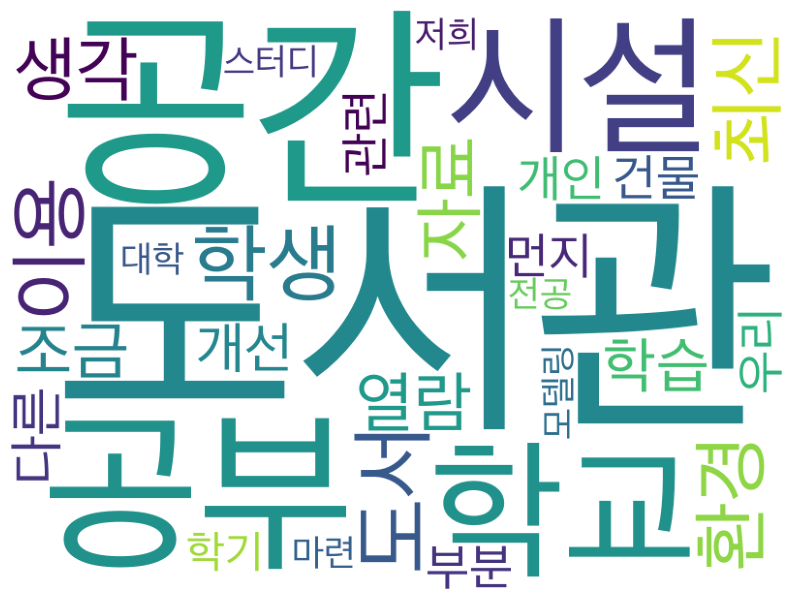

In [12]:
# 4. WordCloud 생성 및 시각화
# 한글 깨짐 방지를 위한 폰트 설정 및 워드클라우드 기본 옵션(배경색, 가로/세로 크기) 지정
# 윈도우 경로: font_path='C:/Windows/Fonts/malgun.ttf',
wordcloud = WordCloud(
    font_path="/System/Library/Fonts/AppleSDGothicNeo.ttc",
    background_color="white",
    width=800,
    height=600,
)

# 상위 30개 튜플 리스트(tags)를 딕셔너리 구조({'단어': 빈도수})로 변환하여 출력
print(dict(tags))

# 딕셔너리 형태의 빈도 데이터를 입력받아 워드클라우드 이미지 생성
cloud = wordcloud.generate_from_frequencies(dict(tags))

# 캔버스 그래프 틀 생성 (가로 10인치, 세로 8인치)
plt.figure(figsize=(10, 8))

# 워드클라우드 이미지 축의 눈금(x, y축 척도)을 숨김 처리
plt.axis("off")

# 생성된 워드클라우드 이미지를 matplotlib 캔버스에 렌더링
plt.imshow(cloud)

# 최종 워드클라우드 시각화 출력
plt.show()

In [13]:
# 단어 요소들의 빈도수를 쉽게 계산하기 위한 Counter 클래스 가져오기
from collections import Counter

line = ["장난감", "스마트폰", "컴퓨터", "스마트폰", "컴퓨터", "컴퓨터"]

# 빈도수 계산
counts = Counter(line)

# Counter({'컴퓨터': 3, '스마트폰': 2, '장난감': 1})
print(counts)

# [('컴퓨터', 3)]
print(counts.most_common(1))

Counter({'컴퓨터': 3, '스마트폰': 2, '장난감': 1})
[('컴퓨터', 3)]


## 감정분석


In [14]:
# ==========================================
# 1. 환경 설정 및 형태소 분석기 초기화
# ==========================================

# KoNLPy에서 Okt 형태소 분석기 불러오기
from konlpy.tag import Okt

# Okt 형태소 분석기 인스턴스 생성 (기존 rhinoMorph 대체)
okt = Okt()

In [15]:
# ==========================================
# 2. 사전을 이용한 감성분석 (Rule-based)
# ==========================================

# 파일 읽기 함수 정의 (기본 인코딩: cp949)
def read_data(filename, encoding="cp949"):
    # 지정한 파일 경로의 텍스트 파일을 읽기 모드로 열기
    with open(filename, "r", encoding=encoding) as f:
        # 각 줄을 탭('\t') 기호 기준으로 분리하여 리스트로 생성
        data = [line.split("\t") for line in f.read().splitlines()]
        # txt 파일의 첫 번째 줄(헤더: id, document, label)은 제외
        data = data[1:]
    # 처리된 데이터 리스트 반환
    return data


# 파일 쓰기 함수 정의
def write_data(data, filename, encoding="cp949"):
    # 지정한 파일 경로에 쓰기 모드로 파일 열기
    with open(filename, "w", encoding=encoding) as f:
        # 데이터를 파일에 기록
        f.write(data)


# 형태 분석이 완료된 데이터 로딩 (윈도우 환경에 맞게 경로 및 파일 지정)
data = read_data("data/emotion/ratings_morphed.txt", encoding="cp949")

# 전체 로딩된 데이터의 개수(행 수) 출력
print(f"전체 로딩된 데이터 개수: {len(data)}")
# 데이터의 첫 번째 행의 컬럼 수 출력
print(f"첫 번째 행의 컬럼 수: {len(data[0])}")
# 데이터의 첫 번째 행 내용 확인
print(f"첫 번째 행 내용: {data[0]}")

# 데이터 리스트에서 ID 컬럼만 추출
data_id = [line[0] for line in data]
# 데이터 리스트에서 본문 텍스트 컬럼만 추출
data_text = [line[1] for line in data]
# 데이터 리스트에서 기존 긍/부정 라벨(1: 긍정, 0: 부정)만 추출
data_senti = [line[2] for line in data]

# 긍정 감정 단어 사전 파일 읽기
positive = read_data("data/emotion/positive.txt", encoding="cp949")
# 부정 감정 단어 사전 파일 읽기
negative = read_data("data/emotion/negative.txt", encoding="cp949")


# 한 줄의 문장 내에서 감정 사전에 속한 단어의 개수를 카운트하는 함수 정의
def cntWordInLine(data, senti):
    # 감정 단어 발견 카운트 결과를 저장할 빈 리스트
    senti_found = []
    # 데이터셋의 문장들을 하나씩 순회
    for onedata in data:
        # 띄어쓰기 기준으로 문장 내 단어들을 분리
        oneline_word = onedata.split(" ")
        # 해당 문장에서 발견된 감정 단어 수를 저장할 임시 변수
        senti_temp = 0
        # 감정 사전의 각 단어를 순회
        for sentiword in senti:
            # 감정 사전의 단어가 현재 문장의 단어 리스트에 존재하는지 검사
            if sentiword[0] in oneline_word:
                # 단어가 존재하는 경우 카운트 1 증가
                senti_temp += 1
        # 문장에서 카운트된 감정 단어 총 개수를 결과 리스트에 추가
        senti_found.append(senti_temp)
    # 문장별 감정 단어 카운트 리스트 반환
    return senti_found


# 각 문장별로 발견된 긍정 단어의 개수 파악
data_senti_poscnt = cntWordInLine(data_text, positive)
# 각 문장별로 발견된 부정 단어의 개수 파악
data_senti_negcnt = cntWordInLine(data_text, negative)


# 긍정 단어 카운트 상위 20개 출력
print(f"긍정 단어 개수: {len(data_senti_poscnt)}")
print(f"긍정 단어 상위 20개: {data_senti_poscnt[:20]}")

# 부정 단어 카운트 상위 20개 출력
print(f"부정 단어 개수: {len(data_senti_negcnt)}")
print(f"부정 단어 상위 20개: {data_senti_negcnt[:20]}")

전체 로딩된 데이터 개수: 197447
첫 번째 행의 컬럼 수: 3
첫 번째 행 내용: ['8132799', '디자인 배우 학생 외국 디자이너 일군 전통 통하 발전하 가 문화 산업 부럽 사실 우리나라 그 어렵 시절 끝 열정 지키 노라노 같 전통 있 같 사람 꿈 꾸 이루 나가 있 감사하', '1']
긍정 단어 개수: 197447
긍정 단어 상위 20개: [5, 1, 0, 0, 2, 1, 0, 0, 0, 1, 1, 1, 0, 1, 2, 0, 1, 0, 1, 0]
부정 단어 개수: 197447
부정 단어 상위 20개: [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1]


In [16]:
# Pandas 패키지 불러오기
import pandas as pd

# 추출된 컬럼들과 감정 단어 카운트를 모아 Pandas 데이터프레임 생성
newdata = pd.DataFrame(
    {
        "id": data_id,
        "text": data_text,
        "original": data_senti,
        "pos": data_senti_poscnt,
        "neg": data_senti_negcnt,
    }
)

In [17]:
# 긍정 단어 개수에서 부정 단어 개수를 차감하여 감정 점수 계산
senti_score = newdata["pos"] - newdata["neg"]
# 계산된 감정 점수를 데이터프레임의 'senti_score' 컬럼에 저장
newdata["senti_score"] = senti_score

# 감정 점수가 0보다 큰 경우 새로운 예측 라벨(new)을 1(긍정)로 설정
newdata.loc[newdata.senti_score > 0, "new"] = 1
# 감정 점수가 0 이하인 경우 새로운 예측 라벨(new)을 0(부정)으로 설정
newdata.loc[newdata.senti_score <= 0, "new"] = 0

# 원래 라벨(original)과 사전에 의해 계산된 라벨(new)이 일치하면 True로 판정
newdata.loc[pd.to_numeric(newdata.original) == newdata.new, "matched"] = "True"
# 원래 라벨과 계산된 라벨이 일치하지 않으면 False로 판정
newdata.loc[pd.to_numeric(newdata.original) != newdata.new, "matched"] = "False"

# 사전 기반 예측의 일치 비율(정확도) 계산 및 출력
score = (
    newdata.matched.str.count("True").sum()
    / (
        newdata.matched.str.count("True").sum()
        + newdata.matched.str.count("False").sum()
    )
    * 100
)
print("사전 기반 정확도:", score)

# 결과를 CSV 파일로 저장 (윈도우 엑셀 호환을 위해 cp949 인코딩 사용)
newdata.to_csv("newfile.csv", sep=",", encoding="cp949", index=False)
# 결과를 TXT 파일로 저장 (탭 구분자 사용)
newdata.to_csv("newfile2.txt", sep="\t", encoding="cp949", index=False)

사전 기반 정확도: 62.40459465071639


In [18]:
# 수학 연산을 위한 math 패키지 불러오기
import math


# 시그모이드(Sigmoid) 활성화 함수 정의
def sigmoid(x):
    # 감정 점수를 0~1 사이의 확률값 형태로 변환하는 공식을 적용하여 반환
    return 1 / (1 + math.exp(-x))


# 감정 점수(senti_score) 컬럼에 시그모이드 함수를 적용하여 새로운 컬럼 생성
newdata["sigmoid"] = newdata.senti_score.apply(sigmoid)

# 데이터프레임 출력 시 최대 열 개수 제한 설정 확장
pd.set_option("display.max_columns", 10)
# 정제된 최종 상위 5개 행 데이터 확인
print(newdata.iloc[:5, :])

         id                                               text original  pos  \
0   8132799  디자인 배우 학생 외국 디자이너 일군 전통 통하 발전하 가 문화 산업 부럽 사실 우...        1    5   
1   4655635                                  폴리스스토리 시리즈 뉴 없 최고        1    1   
2   9251303                와 연기 진짜 쩔 지루하 생각하 몰입하 보 그래 이런 진짜 영화        1    0   
3  10067386                              안개 자욱하 밤하늘 뜨 초승달 같 영화        1    0   
4   2190435                               사랑 해보 사람 처음 끝 웃 있 영화        1    2   

   neg  senti_score  new matched   sigmoid  
0    1            4  1.0    True  0.982014  
1    0            1  1.0    True  0.731059  
2    1           -1  0.0   False  0.268941  
3    0            0  0.0   False  0.500000  
4    0            2  1.0    True  0.880797  


In [19]:
# ==========================================
# 3. 머신러닝을 이용한 감성분석 (Machine Learning)
# ==========================================

# Scikit-learn의 train_test_split 함수 불러오기
from sklearn.model_selection import train_test_split

# 데이터셋을 훈련용 데이터와 테스트용 데이터로 무작위 분리 (75% : 25%)
train_data_text, test_data_text, train_data_senti, test_data_senti = train_test_split(
    data_text, data_senti, stratify=data_senti
)

# 단어 빈도 카운트를 위한 Collections의 Counter 클래스 불러오기
from collections import Counter

# 훈련 데이터의 긍/부정 클래스 비율 확인
train_data_senti_freq = Counter(train_data_senti)
print("train_data_senti_freq:", train_data_senti_freq)

# 테스트 데이터의 긍/부정 클래스 비율 확인
test_data_senti_freq = Counter(test_data_senti)
print("test_data_senti_freq:", test_data_senti_freq)


# 텍스트 단어 카운트 기반 벡터화(CountVectorizer) 클래스 불러오기
from sklearn.feature_extraction.text import CountVectorizer

# 최소 5회 이상 등장한 단어들로만 단어 사전을 학습(fit)
vect = CountVectorizer(min_df=5).fit(train_data_text)

# 학습된 단어 사전을 바탕으로 훈련 데이터를 희소 행렬(Sparse Matrix)로 변환
X_train = vect.transform(train_data_text)
# 생성된 훈련 데이터 행렬의 규격 및 정보 출력
print("X_train:\n", repr(X_train))

# 벡터라이저가 추출한 특성(단어) 목록 가져오기
feature_names = vect.get_feature_names_out()
# 추출된 전체 단어(특성) 개수 출력
print("특성 개수:", len(feature_names))
# 추출된 단어 중 앞부분 20개 출력
print("처음 20개 특성:\n", feature_names[:20])


# 머신러닝 분류 알고리즘인 로지스틱 회귀(Logistic Regression) 불러오기
from sklearn.linear_model import LogisticRegression

# 훈련 데이터의 타겟 라벨을 Pandas Series 형태로 변환
y_train = pd.Series(train_data_senti)

# 윈도우 환경에서 안정적인 liblinear 솔버 기반의 로지스틱 회귀 모델 생성
lr = LogisticRegression(solver="liblinear")
# 훈련 데이터(X_train)와 정답 라벨(y_train)로 모델 학습 수행
lr.fit(X_train, y_train)

# 테스트 데이터를 훈련된 단어 사전에 맞게 행렬 변환
X_test = vect.transform(test_data_text)
# 테스트 데이터의 타겟 라벨을 Pandas Series 형태로 변환
y_test = pd.Series(test_data_senti)

# 학습된 모델을 테스트 데이터에 적용하여 예측 정확도(Score) 출력
print("머신러닝 모델 테스트 데이터 점수:", lr.score(X_test, y_test))

train_data_senti_freq: Counter({'1': 74098, '0': 73987})
test_data_senti_freq: Counter({'1': 24699, '0': 24663})
X_train:
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 821839 stored elements and shape (148085, 12374)>
특성 개수: 12374
처음 20개 특성:
 ['007' '10점' '1빠' '24' 'ai' 'cgv' 'ebs' 'kbs' 'la' 'mb' 'mbc' 'naver'
 'new' 'ok' 'sbs' 'sns' 'tv' 'ㄴㄴ' 'ㄷㄷ' 'ㅂㄷㅂㄷ']
머신러닝 모델 테스트 데이터 점수: 0.8094688221709007


In [20]:
# ==========================================
# 4. 단일 새로운 문장 1개 감성 예측 (KoNLPy 사용)
# ==========================================

# 예측하고자 하는 새로운 테스트 문장 입력
new_input = "오늘은 정말 재미있는 하루구나!"
new_input = "너무 재미없어. 시간 아까워 !"

# Okt 형태소 분석기를 활용해 명사, 형용사, 부사, 동사 등 주요 품사 추출 진행
# morphs 함수로 형태소 단위 분할 진행
morphed_tokens = okt.morphs(new_input)

# 형태소 분할된 단어 리스트를 하나의 공백으로 연결된 문자열 형태로 재구성
morphed_input = " ".join(morphed_tokens)

# 머신러닝 모델 입력 형식에 맞추기 위해 리스트 구조로 포장
inputdata = [morphed_input]
# 전처리 완료된 입력 데이터 형태 확인
print("input data:", inputdata)

# 기존에 학습시킨 CountVectorizer 단어 사전을 이용해 희소 행렬로 변환
X_input = vect.transform(inputdata)
print(X_input)
print(f"7515: {feature_names[7515]}")
print(f"9342: {feature_names[9342]}")
print(f"11566: {feature_names[11566]}")

# 학습 완료된 로지스틱 회귀 모델로 긍정(1)/부정(0) 예측값 계산
result = lr.predict(X_input)

# 예측 결과값이 '0'일 경우 부정 메시지 출력
if result[0] == "0" or result[0] == 0:
    print("부정적인 글입니다")
# 예측 결과값이 '1'일 경우 긍정 메시지 출력
else:
    print("긍정적인 글입니다")

input data: ['너무 재미없어 . 시간 아까워 !']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (1, 12374)>
  Coords	Values
  (0, 1895)	1
  (0, 6077)	1
7515: 오오오
9342: 정이
11566: 하품
부정적인 글입니다


In [21]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

data_text = [
    "어리 때 다시 보 재미있 ㅋㅋ",
    "폴리스스토리 시리즈 뉴 없 최고",
    "디자인 배우 학생 외국 디자이너 일군 전통 통하 발전하 가 문화 산업 부럽 사실 우리나라 그 어렵 시절 끝 열정 지키 노라노 같 전통 있 같 사람 꿈 꾸 이루 나가 있 감사하",
    "안개 자욱하 밤하늘 뜨 초승달 같 영화",
]

# data_text = Counter(x)
# print(data_text)
vect = CountVectorizer(min_df=1).fit(data_text)


# 1. 추출된 특성(단어 사전) 확인
print("추출된 단어 목록:", vect.get_feature_names_out())
# 출력: ['같']

# 2. 문장들을 수치 행렬로 변환 (transform)
X_data = vect.transform(data_text)

# 3. Dense Matrix 형태로 확인
print("\n문장별 단어 출현 빈도 행렬:")
print(X_data.toarray())
# 출력:
# [[0]   <- 1번 문장 ('같' 0회)
#  [0]   <- 2번 문장 ('같' 0회)
#  [1]   <- 3번 문장 ('같' 등장)
#  [1]]  <- 4번 문장 ('같' 등장)


추출된 단어 목록: ['ㅋㅋ' '감사하' '나가' '노라노' '다시' '디자이너' '디자인' '문화' '발전하' '밤하늘' '배우' '부럽' '사람'
 '사실' '산업' '시리즈' '시절' '안개' '어렵' '어리' '열정' '영화' '외국' '우리나라' '이루' '일군' '자욱하'
 '재미있' '전통' '지키' '초승달' '최고' '통하' '폴리스스토리' '학생']

문장별 단어 출현 빈도 행렬:
[[1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 0 1 1 1 1 0 0 2 1 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0]]
